# Regression approach but using Sushma's data so it's not helpful

### 0. Assume we have done the ABM simulation and the datasets are graph-structured

All the graph-structured datasets we need here are in the main file named 'finaldata'.

### 1. Install Packages

In [1]:
pip install torch_geometric

     ---------------------------------------- 1.1/1.1 MB 14.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install tensorboard

     ---------------------------------------- 5.5/5.5 MB 17.6 MB/s eta 0:00:00
     ---------------------------------------- 4.3/4.3 MB 13.6 MB/s eta 0:00:00
     ------------------------------------- 431.0/431.0 kB 26.3 MB/s eta 0:00:00
     -------------------------------------- 135.6/135.6 kB 7.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [20]:
pip install tsne_torch

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for tsne_torch: filename=tsne_torch-1.0.1-py3-none-any.whl size=5618 sha256=62b68f983bad4a09d71d7812d28247f7dbae7a0e31063ec4ac7dd2023ba22c5d
  Stored in directory: c:\users\mechrev\appdata\local\pip\cache\wheels\13\2b\52\810d21c5fabc59220484813a0916b8bd0f11860aea27eda609
Successfully built tsne_torch
Note: you may need to restart the kernel to use updated packages.


### 2. Import packages

In [1]:
import os
import time
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from collections import defaultdict
from tqdm import tqdm
import random
from itertools import combinations, permutations, product
from torch.utils.data import DataLoader
from torch.optim import Adam
import matplotlib.pyplot as plt
import re
from collections import defaultdict
import pickle as pk
from datetime import datetime

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric.utils as pyg_utils
from tsne_torch import TorchTSNE as TSNE
from torch.utils.tensorboard import SummaryWriter
from torch_geometric.utils import from_networkx
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data, Dataset
from torch_geometric.nn import GCNConv, global_mean_pool, GATConv

In [3]:
ur_path = 'C:/Users/MECHREV/Desktop/本硕课程/二硕/Courses/AMATH 900 GNN/Data'  # your path to the data files

### 3. Get file names for all graph samples

Simple_GAT.ipynb

In [4]:
directory = ur_path+"/data files/data files/finaldata"

In [5]:
#folder of the data generated by sims_relationships.ipynb
def get_file_names(directory):

    # Collect files starting with "Trackrefiner"
    matching_files = []
    for root, _, files in os.walk(directory):
        for file in files:
            if file.startswith("Trackrefiner"):
                matching_files.append(os.path.join(root, file))

    return matching_files

In [6]:
matching_files = get_file_names(directory)

In [7]:
matching_files[:3]

['C:/Users/MECHREV/Desktop/本硕课程/二硕/Courses/AMATH 900 GNN/Data/data files/data files/finaldata\\iteration 00\\Trackrefiner.gamma_100_reg_param_0.01_adh_0.01-Average-0result.csv-analysis_013.csv',
 'C:/Users/MECHREV/Desktop/本硕课程/二硕/Courses/AMATH 900 GNN/Data/data files/data files/finaldata\\iteration 00\\Trackrefiner.gamma_100_reg_param_0.01_adh_0.1-Average-0result.csv-analysis_038.csv',
 'C:/Users/MECHREV/Desktop/本硕课程/二硕/Courses/AMATH 900 GNN/Data/data files/data files/finaldata\\iteration 00\\Trackrefiner.gamma_100_reg_param_0.01_adh_1-Average-0result.csv-analysis_079.csv']

In [8]:
len(matching_files)  # 10 iterations and 100 files for each

1000

### 4. Pair parameters uniquely

In [9]:
#Identifying parameter combinations
def identify_parameter_combinations(matching_files):
    variations_with_instances = np.unique(list(map(lambda x: x.split('Trackrefiner.')[1].split('result')[0], matching_files)))

    # Initialize sets to collect unique values
    unique_gamma = set()
    unique_reg_param = set()
    unique_adh = set()
    unique_average = set()


    # Extract parameter values
    for var in variations_with_instances:
        # Remove the instance part
        base_var, average = var.split('-Average-')
        uni_average = average[0]
        # Parse the gamma, reg_param, and adh values
        parts = base_var.split('_')
        gamma = parts[1]
        reg_param = parts[4]
        adh = parts[6]

        # Add to respective sets
        unique_gamma.add(gamma)
        unique_reg_param.add(reg_param)
        unique_adh.add(adh)
        unique_average.add(uni_average)

    # Convert to sorted lists (optional)
    unique_gamma = list(sorted(unique_gamma))
    unique_reg_param = list(sorted(unique_reg_param))
    unique_adh = list(sorted(unique_adh))
    return unique_gamma, unique_reg_param, unique_adh

In [10]:
unique_gamma, unique_reg_param, unique_adh = identify_parameter_combinations(matching_files)

In [11]:
unique_gamma

['10', '100', '20', '40']

In [12]:
unique_reg_param

['0.01', '0.05', '0.1', '0.5', '1']

In [13]:
unique_adh

['0.01', '0.1', '1', '10', '100']

In [14]:
# Generate the data structure for 3 parameters
def get_paramter_set_simulations(gamma_values, reg_param_values, adh_values):
    data = {
        f"gamma_{gamma}_reg_param_{reg_param}_adh_{adh}": [
            f"gamma_{gamma}_reg_param_{reg_param}_adh_{adh}-Average-{avg}" 
            for avg in average_values
        ]
        for gamma, reg_param, adh in product(gamma_values, reg_param_values, adh_values)
    }
    return data

In [15]:
#number of simulation instances for every parameter combination generated from ABM
n_simulation_instances = 10

In [16]:
average_values = [str(i) for i in range(n_simulation_instances)]

In [17]:
average_values

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

In [18]:
data = get_paramter_set_simulations(unique_gamma, unique_reg_param, unique_adh)  ## run this line for a complete modeling
# data = get_paramter_set_simulations(unique_gamma[:2], unique_reg_param[:2],)  ## run this line for a quick review

In [19]:
list(data.keys())[:3]

['gamma_10_reg_param_0.01_adh_0.01',
 'gamma_10_reg_param_0.01_adh_0.1',
 'gamma_10_reg_param_0.01_adh_1']

In [20]:
data[list(data.keys())[0]][:3]

['gamma_10_reg_param_0.01_adh_0.01-Average-0',
 'gamma_10_reg_param_0.01_adh_0.01-Average-1',
 'gamma_10_reg_param_0.01_adh_0.01-Average-2']

In [21]:
len(list(data.keys()))

100

In [22]:
len(unique_gamma)*len(unique_reg_param)*len(unique_adh)  # 4x5=20

100

In [23]:
len(unique_gamma)*len(unique_reg_param)*len(unique_adh)*len(average_values)  # total amount of files starting with 'Trackrefiner'

1000

### 5. Alternative way to pair parameters uniquely

In [24]:
# Generate the data structure for 2 parameters
# Only helpful if we want to only use the 2 parameters with Sushma's data
def get_paramter_set_simulations(gamma_values, reg_param_values, adh_values):
    data_2params = {}
    for gamma, reg_param, adh in product(gamma_values, reg_param_values, adh_values):
        if f"gamma_{gamma}_reg_param_{reg_param}" in list(data_2params.keys()):
            data_2params[f"gamma_{gamma}_reg_param_{reg_param}"] += [f"gamma_{gamma}_reg_param_{reg_param}_adh_{adh}-Average-{avg}" for avg in average_values]
        else: 
            data_2params[f"gamma_{gamma}_reg_param_{reg_param}"] = [f"gamma_{gamma}_reg_param_{reg_param}_adh_{adh}-Average-{avg}" for avg in average_values]
    return data_2params

In [25]:
data_2params = get_paramter_set_simulations(unique_gamma, unique_reg_param, unique_adh)  ## run this line for a complete modeling
# data = get_paramter_set_simulations(unique_gamma[:2], unique_reg_param[:2],)  ## run this line for a quick review

In [26]:
list(data_2params.keys())[:3]

['gamma_10_reg_param_0.01',
 'gamma_10_reg_param_0.05',
 'gamma_10_reg_param_0.1']

In [27]:
data_2params[list(data_2params.keys())[0]][:3]

['gamma_10_reg_param_0.01_adh_0.01-Average-0',
 'gamma_10_reg_param_0.01_adh_0.01-Average-1',
 'gamma_10_reg_param_0.01_adh_0.01-Average-2']

In [28]:
len(list(data_2params.keys()))

20

In [29]:
counter = 0
for k,v in data_2params.items():
    counter += len(v)
counter  # 20 pairs of parameters, 500 graph samples for each, 1000 graph samples in total 

1000

### 6. Correspond the edge and feature csv files to their sample indices

In [30]:
#this function will have a simulation instance as key and the values as [node_features, node_relationships]
def generate_simulation_ditionary(file_list):
    # Regex pattern to extract parameter combinations and Average instance
    pattern = re.compile(r"gamma_(\d+)_reg_param_(\d+\.?\d*)_adh_(\d+\.?\d*)-Average-(\d+)")

    # Dictionary to store the key-value pairs
    parameter_dict = defaultdict(list)

    # Process each filename
    for file in file_list:
        match = pattern.search(file)
        if match:
            # Extract values
            gamma, reg_param, adh, average = match.groups()
            # Create key as parameter combination
            key = f"gamma_{gamma}_reg_param_{reg_param}_adh_{adh}-Average-{average}"
            # Append the Average instance to the key's list
            parameter_dict[key] = [file, file.split('Trackrefiner')[0] + 'ObjectRelationship.Trackrefiner' + file.split('Trackrefiner')[1]]

    # Convert defaultdict to a regular dictionary
    parameter_dict = dict(parameter_dict)
    return parameter_dict

In [31]:
def incomplete_file_list(matching_files):
    F = []
    for f in matching_files:
        for t in data_2params.keys():
            if f.find(t) >= 0:
                F.append(f)
    return F

In [32]:
file_list = matching_files  ## run this line for a complete modeling
# file_list = incomplete_file_list(matching_files)  ## run this line for a quick review
parameter_dict = generate_simulation_ditionary(file_list)

In [33]:
len(file_list), len(matching_files)

(1000, 1000)

In [34]:
list(parameter_dict.keys())[:3]

['gamma_100_reg_param_0.01_adh_0.01-Average-0',
 'gamma_100_reg_param_0.01_adh_0.1-Average-0',
 'gamma_100_reg_param_0.01_adh_1-Average-0']

In [35]:
parameter_dict[list(parameter_dict.keys())[0]]

['C:/Users/MECHREV/Desktop/本硕课程/二硕/Courses/AMATH 900 GNN/Data/data files/data files/finaldata\\iteration 00\\Trackrefiner.gamma_100_reg_param_0.01_adh_0.01-Average-0result.csv-analysis_013.csv',
 'C:/Users/MECHREV/Desktop/本硕课程/二硕/Courses/AMATH 900 GNN/Data/data files/data files/finaldata\\iteration 00\\ObjectRelationship.Trackrefiner.gamma_100_reg_param_0.01_adh_0.01-Average-0result.csv-analysis_013.csv']

In [36]:
len(list(parameter_dict.keys()))

1000

### 7. Read data files and generate graph-structured data (no need to run it if it has been saved)

In [73]:
def flatten_node_attributes(node_attr):
        """Flatten the node attributes to ensure all values are numeric."""
        flat_attrs = []
        for attr in node_attr.values():
            if isinstance(attr, (tuple, list)):
                flat_attrs.extend(attr)
            else:
                flat_attrs.append(attr)
        return flat_attrs

In [106]:
pd.read_csv("C:/Users/MECHREV/Desktop/本硕课程/二硕/Courses/AMATH 900 GNN/Data/data files/data files/finaldata/iteration 00/ObjectRelationship.Trackrefiner.gamma_10_reg_param_0.01_adh_0.01-Average-0result.csv-analysis_063.csv").head(2)

,Unnamed: 0,Relationship,First Image Number,First Object Number,Second Image Number,Second Object Number
0,0,Parent,1,1,0,0
1,1,Parent,2,1,1,1


In [107]:
pd.read_csv("C:/Users/MECHREV/Desktop/本硕课程/二硕/Courses/AMATH 900 GNN/Data/data files/data files/finaldata/iteration 00/Trackrefiner.gamma_10_reg_param_0.01_adh_0.01-Average-0result.csv-analysis_063.csv").head(2)

,Id,ImageName,stepNum,YFP,ObjectNumber,AreaShape_Area,AreaShape_Center_X,AreaShape_Center_Y,length,AreaShape_MinorAxisLength,...,startVol,targetVol,pos,time,radius,dir,ends,strainRate,strainRate_rolling,unknown_cell_type
0,1,0,1,1,1,14.137167,0.0,0.0,0.504000,0.072,...,0.504,1.104326,"[0.0, 0.0]",3.0,0.036,"[6.123233995736766e-17, -1.0]","[[1.543054966925665e-17, -0.252], [-1.54305496...",0.000000,0.000000,False
1,1,10,2,1,1,19.417730,0.0,0.0,0.746043,0.072,...,0.504,1.104326,"[0.0, 0.0]",6.0,0.036,"[6.123233995736766e-17, -1.0]","[[2.2840984295966158e-17, -0.3730215816], [-2....",0.480244,0.240122,False


In [108]:
# pd.read_csv("C:/Users/MECHREV/Desktop/本硕课程/二硕/Courses/AMATH 900 GNN/Data/data files/data files/finaldata/iteration 00/Trackrefiner.gamma_10_reg_param_0.01_adh_0.01-Average-0result.csv-analysis_063.csv").columns.to_list()

In [74]:
def load_graph_data(graph_ID, node_features_file, edge_features_file):
    
    # Create the y vector, y = [gamma, reg_param]
    split_list = graph_ID[:-10].split('_')
    y1 = float(split_list[1])
    y2 = float(split_list[4])

    y = torch.tensor([[y1],
                      [y2]], dtype=torch.float)
    
    # Read though the csv files and create the df
    node_features_df = pd.read_csv(node_features_file)  # now finally read the files to get node datasets
    edge_features_df = pd.read_csv(edge_features_file)  # now finally read the files to get edge datasets

    node_features_df['pos'] = node_features_df['pos'].apply(eval).apply(lambda x: tuple(map(float, x)))
    node_features_df['dir'] = node_features_df['dir'].apply(eval).apply(lambda x: tuple(map(float, x)))
    node_features_df[['ends0', 'ends1']] = node_features_df['ends'].apply(eval).apply(pd.Series)
    node_features_df['ends0'] = node_features_df['ends0'].apply(lambda x: tuple(map(float, x)))
    node_features_df['ends1'] = node_features_df['ends1'].apply(lambda x: tuple(map(float, x)))

     # Select required columns and ensure they are numeric
    include_columns = ['stepNum', 'id', 'ObjectNumber', 'parent_id', 'label', 'cellType', 'divideFlag',
                       'LifeHistory', 'startVol', 'targetVol', 'radius', 'length', 'strainRate', 'strainRate_rolling',
                       'pos', 'dir', 'ends0', 'ends1']
    node_features_df = node_features_df[include_columns]

    # Create the graph
    G = nx.MultiDiGraph()

    # Add nodes with their features as attributes and label them by their index
    for idx, row in node_features_df.iterrows():
        node_id = idx  # Use the index as a unique label for each node
        G.add_node(node_id, **row.to_dict())

    # Define positions for the entire graph
    pos = {node: data['pos'] for node, data in G.nodes(data=True)}

    # Create a unique mapping from (stepNum, ObjectNum) to node index
    node_mapping = {(row['stepNum'], row['ObjectNumber']): idx for idx, row in node_features_df.iterrows()}
    contact_edges = []
    # Add edges, considering contact edges
    for _, row in edge_features_df.iterrows():
        if row['Relationship'] == 'Neighbors':
            step_num_1 = row['First Image Number']
            step_num_2 = row['Second Image Number']
            node1 = row['First Object Number']
            node2 = row['Second Object Number']

            if (step_num_1, node1) in node_mapping and (step_num_2, node2) in node_mapping:
                if not G.has_edge(node_mapping[(step_num_1, node1)], node_mapping[(step_num_2, node2)]):
                    node1_idx = node_mapping[(step_num_1, node1)]
                    node2_idx = node_mapping[(step_num_2, node2)]
                    G.add_edge(node1_idx, node2_idx, edge_type = 'contact')
                    G.add_edge(node2_idx, node1_idx, edge_type = 'contact')
                    contact_edges.append((node1_idx, node2_idx))
                    contact_edges.append((node2_idx, node1_idx))

    # Create lineage mapping
    lineage_mapping = {(row['id'], row['parent_id'], row['stepNum']): idx for idx, row in node_features_df.iterrows()}
    lineage_edges = []
    # Add directed lineage edges based on the lineage mapping
    for key, node1_idx in lineage_mapping.items():
        id, parent_id, step_num = key
        if parent_id == 0:
            continue  # Skip if parent_id is zero
        if (id, id, step_num + 1) in lineage_mapping:
            node2_idx = lineage_mapping[(id, id, step_num + 1)]
            G.add_edge(node1_idx, node2_idx, edge_type='lineage')
            lineage_edges.append((node1_idx, node2_idx))
        elif (id, parent_id, step_num + 1) in lineage_mapping:
            node2_idx = lineage_mapping[(id, parent_id, step_num + 1)]
            G.add_edge(node1_idx, node2_idx, edge_type='lineage')
            lineage_edges.append((node1_idx, node2_idx))
        else:
            for parent_key, node2_idx in lineage_mapping.items():
                parent_id_key, _, step_num_key = parent_key
                if parent_id_key == parent_id and step_num_key == step_num - 1:
                    G.add_edge(node2_idx, node1_idx, edge_type='lineage')
                    lineage_edges.append((node2_idx, node1_idx))
                    break


    x = torch.tensor([flatten_node_attributes(G.nodes[node]) for node in G.nodes()], dtype=torch.float)
    contact_edge_index = torch.tensor(contact_edges, dtype=torch.long).t().contiguous()
    lineage_edge_index = torch.tensor(lineage_edges, dtype=torch.long).t().contiguous()

    data =  Data(x, contact_edge_index=contact_edge_index, lineage_edge_index=lineage_edge_index, y=y)
    return data

In [110]:
node_features_file = parameter_dict[list(parameter_dict.keys())[0]][0]

In [111]:
node_features_df = pd.read_csv(node_features_file)
node_features_df['pos'] = node_features_df['pos'].apply(eval).apply(lambda x: tuple(map(float, x)))
node_features_df['dir'] = node_features_df['dir'].apply(eval).apply(lambda x: tuple(map(float, x)))
node_features_df[['ends0', 'ends1']] = node_features_df['ends'].apply(eval).apply(pd.Series)
node_features_df['ends0'] = node_features_df['ends0'].apply(lambda x: tuple(map(float, x)))
node_features_df['ends1'] = node_features_df['ends1'].apply(lambda x: tuple(map(float, x)))

# Select required columns and ensure they are numeric
include_columns = ['stepNum', 'id', 'ObjectNumber', 'parent_id', 'label', 'cellType', 'divideFlag',
                       'LifeHistory', 'startVol', 'targetVol', 'radius', 'length', 'strainRate', 'strainRate_rolling',
                       'pos', 'dir', 'ends0', 'ends1']
node_features_df = node_features_df[include_columns]
node_features_df.head()

,stepNum,id,ObjectNumber,parent_id,label,cellType,divideFlag,LifeHistory,startVol,targetVol,radius,length,strainRate,strainRate_rolling,pos,dir,ends0,ends1
0,1,1,1,0,1,1,True,3,0.504000,1.104326,0.036,0.504000,0.000000,0.000000,"(0.0, 0.0)","(6.123233995736766e-17, -1.0)","(1.543054966925665e-17, -0.252)","(-1.543054966925665e-17, 0.252)"
1,2,1,1,0,1,1,True,3,0.504000,1.104326,0.036,0.746043,0.480244,0.240122,"(0.0, 0.0)","(6.123233995736766e-17, -1.0)","(2.2840984295966158e-17, -0.3730215816)","(-2.2840984295966158e-17, 0.3730215816)"
2,3,1,1,0,1,1,True,3,0.504000,1.104326,0.036,1.104326,0.480244,0.320163,"(0.0, 0.0)","(6.123233995736766e-17, -1.0)","(3.381023669167911e-17, -0.5521630679999999)","(-3.381023669167911e-17, 0.5521630679999999)"
3,4,2,1,1,1,1,True,2,0.747077,1.104089,0.036,0.747077,0.000000,0.000000,"(-0.4259889648, -0.0015915120479999998)","(0.00019068203189582112, -0.9999999818201812)","(-0.42591773774347325, -0.3751298812570852)","(-0.4260601918565267, 0.37194685716108516)"
4,4,3,2,1,1,1,True,2,0.684733,1.011916,0.036,0.684733,0.000000,0.000000,"(0.43266686399999993, 0.0017087628959999998)","(0.00022956770753082537, -0.9999999736493335)","(0.4327454602879489, -0.3406577080823547)","(0.43258826771205094, 0.34407523387435474)"


In [112]:
start_time = time.time()
data_tuple = {}
counter = 0
for key in parameter_dict.keys():
    data_tuple[key] = load_graph_data(key, parameter_dict[key][0], parameter_dict[key][1])
    counter += 1
    if counter == 1:
        df = pd.DataFrame(load_graph_data(key, parameter_dict[key][0], parameter_dict[key][1]).x.cpu().numpy())
        df.columns = [f'f{i}' for i in range(load_graph_data(key, parameter_dict[key][0], parameter_dict[key][1]).x.shape[1])]
        display(df.head())
        print('0.1% completed')
    elif counter == 10:
        print('1% completed')
    elif counter == 100:
        print('10% completed')
    elif counter == 500:
        print('50% completed')
    elif counter == 1000:
        print('100% completed')
        
# check the training duration
end_time = time.time()
print(f"Computing time: {end_time - start_time:.2f} seconds")

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21
0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,3.0,0.504000,1.104326,...,0.000000,0.000000,0.000000,0.000000,6.123234e-17,-1.0,1.543055e-17,-0.252000,-1.543055e-17,0.252000
1,2.0,1.0,1.0,0.0,1.0,1.0,1.0,3.0,0.504000,1.104326,...,0.480244,0.240122,0.000000,0.000000,6.123234e-17,-1.0,2.284098e-17,-0.373022,-2.284098e-17,0.373022
2,3.0,1.0,1.0,0.0,1.0,1.0,1.0,3.0,0.504000,1.104326,...,0.480244,0.320163,0.000000,0.000000,6.123234e-17,-1.0,3.381024e-17,-0.552163,-3.381024e-17,0.552163
3,4.0,2.0,1.0,1.0,1.0,1.0,1.0,2.0,0.747077,1.104089,...,0.000000,0.000000,-0.425989,-0.001592,1.906820e-04,-1.0,-4.259177e-01,-0.375130,-4.260602e-01,0.371947
4,4.0,3.0,2.0,1.0,1.0,1.0,1.0,2.0,0.684733,1.011916,...,0.000000,0.000000,0.432667,0.001709,2.295677e-04,-1.0,4.327455e-01,-0.340658,4.325883e-01,0.344075


0.1% completed
1% completed
10% completed
50% completed
100% completed
Computing time: 3039.70 seconds


In [113]:
list(data_tuple.keys())[:3]

['gamma_100_reg_param_0.01_adh_0.01-Average-0',
 'gamma_100_reg_param_0.01_adh_0.1-Average-0',
 'gamma_100_reg_param_0.01_adh_1-Average-0']

In [114]:
len(list(data_tuple.keys()))

1000

In [115]:
data_tuple[list(data_tuple.keys())[0]]  # this is exactly the data type we need for the GNN training in Pytorch

Data(x=[886, 22], y=[2, 1], contact_edge_index=[2, 8940], lineage_edge_index=[2, 557])

Let's take this sample graph as an example to demonstrate what it means by this "Data(x=[886, 22], contact_edge_index=[2, 8940], lineage_edge_index=[2, 557])".

The "x = [886, 22]" means we have a 886x22 node feature matrix for the sample graph gamma_100_reg_param_0.01_adh_0.01-Average-0. More specifically, 886 is the number of nodes in this graph, and 22 is the number of features for each node. Think of this as the dataframe structure we have in our excel data files. 

The "contact_edge_index=[2, 8940]" represents the contact edges in the graph, encoded using edge index format. It's a tensor of shape [2, 8940], meaning there are 8940 edges and each column contains a pair [source_node, target_node].

The "lineage_edge_index=[2, 557]" represents the lineage edges in the graph, encoded using edge index format. It's a tensor of shape [2, 557], meaning there are 557 edges and each column contains a pair [source_node, target_node].

In this graph example, we have 886 nodes with 22 features each, and we have two types of edges, namely 8940 contact edges and 557 lineage edges in this graph.

### 8. Save the graph-structured data (no need to run it if it's already saved)

In [118]:
main_file = 'data_dict'
dt_now = str(datetime.now())[:10]
graph_structured_data_file = ur_path+'/data files/data files/'+main_file+'/graph-structured_data_'+dt_now+'.pkl'
with open(graph_structured_data_file, 'wb') as f:
    pk.dump(data_tuple, f)

### 9. Load the graph-structured data

In [37]:
main_file = 'data_dict'
file_name = ur_path+'/data files/data files/'+main_file+'/graph-structured_data_2025-06-11.pkl'

with open(file_name, "rb") as file:
    data_tuple = pk.load(file) 

In [38]:
data_tuple[list(data_tuple.keys())[0]]

Data(x=[886, 22], y=[2, 1], contact_edge_index=[2, 8940], lineage_edge_index=[2, 557])

In [39]:
len(list(data_tuple.keys()))

1000

### 10. Split data for training/validating/testing

In [40]:
dataset = list(data_tuple.copy().values())
random.shuffle(dataset)
dataset[:5]

[Data(x=[874, 22], y=[2, 1], contact_edge_index=[2, 11776], lineage_edge_index=[2, 563]),
 Data(x=[1071, 22], y=[2, 1], contact_edge_index=[2, 13626], lineage_edge_index=[2, 620]),
 Data(x=[903, 22], y=[2, 1], contact_edge_index=[2, 9486], lineage_edge_index=[2, 560]),
 Data(x=[925, 22], y=[2, 1], contact_edge_index=[2, 13968], lineage_edge_index=[2, 548]),
 Data(x=[1125, 22], y=[2, 1], contact_edge_index=[2, 12958], lineage_edge_index=[2, 618])]

In [41]:
train_split =0.7
test_split = 0.1
val_split = 0.2

train_size = int(len(dataset)*train_split)
test_size = int(len(dataset)*test_split)
val_size = int(len(dataset)*val_split)

final_train_data = dataset[:train_size]
final_test_data = dataset[train_size:train_size+val_size]
final_val_data = dataset[train_size+val_size:]

In [42]:
len(final_train_data)

700

### 11. Set up the batches for the training

In [43]:
batch_train_size = 25
batch_test_size = 10
batch_val_size = 10

In [44]:
train_loader = DataLoader(final_train_data, batch_size=batch_train_size, shuffle=True)
test_loader = DataLoader(final_test_data, batch_size=batch_test_size, shuffle=True)
val_loader = DataLoader(final_val_data, batch_size=batch_val_size, shuffle=True)

timer = 0
for batch in train_loader: # In this loop, the num of iterations = the num of batches
    timer += 1
    print("Batch #{}:".format(timer))
    
    # [sum-up of nodes for each batch, 22]
    print("-> Node feature shape:", batch.x.shape)
    
    # [2, sum-up of contact edges for each batch]
    print("-> Edge index shape:", batch.contact_edge_index.shape)
    
    # [2, sum-up of lineage edges for each batch]
    print("-> Edge index shape:", batch.lineage_edge_index.shape)
    
    # doesn't mater
    print("-> Batch vector shape:", batch.batch.shape)
    
    # [3 * num of graphs for each batch, 1]
    print("-> Graph-level labels:", batch.y.shape)
    print()
    
    if timer == 1:
        break

Batch #1:
-> Node feature shape: torch.Size([26330, 22])
-> Edge index shape: torch.Size([2, 364368])
-> Edge index shape: torch.Size([2, 16391])
-> Batch vector shape: torch.Size([26330])
-> Graph-level labels: torch.Size([50, 1])



### 12. Set up for the training

In [45]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [46]:
# GAT Block with Attention Mechanism
class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GAT, self).__init__()
        
        # in_channels = input features per node
        # hidden_channels = output per head of 1st layer
        # out_channels = number of classes
        # heads = attention heads in 1st layer
        
        # First GAT layer on contact edges
        self.conv1 = GATConv(in_channels=22, out_channels = hidden_channels, heads=2)
        self.conv2 = GATConv(hidden_channels * 2, out_channels=out_channels, heads=1, concat=False)

        # Second GAT layer on lineage edges
        self.conv3 = GATConv(out_channels, out_channels=hidden_channels, heads=2)
        self.conv4 = GATConv(hidden_channels * 2, out_channels=2, heads=1, concat=False) # might have to change out_channels = 3 since we have 3 parameters as labels


    def forward(self, data):
        
        # Contact message passing
        x, c_edge_index, l_edge_index = data.x, data.contact_edge_index, data.lineage_edge_index
        x = self.conv1(x, c_edge_index)
        x = F.elu(x)
        x = self.conv2(x, c_edge_index)
        x = F.elu(x)

        # Lineage message passing
        x = self.conv3(x, l_edge_index)
        x = F.elu(x)
        x = self.conv4(x, l_edge_index)
        x = F.elu(x)

        # Pool to graph-level prediction (regression)
        x = global_mean_pool(x, data.batch) # shape: [num_graphs, 1]
        return x.view(-1)  # flatten to [num_graphs]

In [47]:
def ssr_loss(pred, target):
    return torch.sum((pred - target) ** 2)

In [48]:
def tss_baseline(target):
    return torch.sum((target - target.mean())**2)

In [49]:
def R_2(ssr, tss):
    return 1 - ssr/tss

In [50]:
def mse_loss(pred, target):
    return ((target - pred)**2).mean()

In [51]:
in_channels_model = 22
hidden_channels_model = 4 #attention heads
feature_embedding_size = 5

In [52]:
# Adjust input/output as needed
model = GAT(in_channels = in_channels_model, hidden_channels = hidden_channels_model, out_channels=feature_embedding_size).to(device)

In [53]:
model_learning_rate = 0.001 #optimizer can be changed and can also be learnt using adaptive learning rates

In [54]:
optimizer = Adam(model.parameters(), lr=model_learning_rate)

### 13. Train the model (no need to run it if it's already saved)

In [65]:
num_epoch = 300

In [64]:
# Train the model using SSR and deriving R^2

start_time = time.time()
patience = 10
best_val_loss = float('inf')
best_epoch = 0
counter = 0
best_model_state = None

epoch_num_list = []
train_loss_list = []
val_loss_list = []

train_R_2_list = []
val_R_2_list = []

for epoch in range(1, num_epoch+1):
    
    # Training
    model.train()
    total_train_loss = 0
    total_train_tss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        pred = model(batch)
        loss = ssr_loss(pred, batch.y.view(-1))
        target = batch.y.view(-1)
        TSS = torch.sum((target - target.mean())**2)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
        total_train_tss += TSS

    # Validation
    model.eval()
    total_val_loss = 0
    total_val_tss = 0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            pred = model(batch)
            loss = ssr_loss(pred, batch.y.view(-1))
            target = batch.y.view(-1)
            TSS = torch.sum((target - target.mean())**2)
            total_val_loss += loss.item()
            total_val_tss += TSS

    epoch_num_list.append(epoch)
    train_loss_list.append(total_train_loss)
    val_loss_list.append(total_val_loss)
    
    train_R_2 = R_2(total_train_loss, total_train_tss)
    val_R_2 = R_2(total_val_loss, total_val_tss)
    
    train_R_2_list.append(train_R_2)
    val_R_2_list.append(val_R_2)
    
    print(f"Epoch {epoch:03d}, Train SSR: {total_train_loss:.4f}, Train R_2: {train_R_2:.4f}, Val SSR: {total_val_loss:.4f}, Val R_2: {val_R_2:.4f}")

    # Early stopping logic
    if total_val_loss < best_val_loss:
        best_val_loss = total_val_loss
        best_epoch = epoch
        counter = 0
        best_model_state = model.state_dict()  # Save the best model
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping triggered at epoch {epoch}. Best epoch: {best_epoch}")
            break

# Load the best model before testing
model.load_state_dict(best_model_state)

# check the training duration
end_time = time.time()
print(f"Training time: {end_time - start_time:.2f} seconds")

Epoch 001, Train SSR: 1808924.3750, Train R_2: -0.2765, Val SSR: 197462.4224, Val R_2: 0.0271
Epoch 002, Train SSR: 1130821.7676, Train R_2: 0.2037, Val SSR: 139845.5391, Val R_2: 0.3007
Epoch 003, Train SSR: 979185.2070, Train R_2: 0.3120, Val SSR: 138063.2041, Val R_2: 0.3155
Epoch 004, Train SSR: 967244.0664, Train R_2: 0.3159, Val SSR: 135811.1416, Val R_2: 0.3152
Epoch 005, Train SSR: 956975.2773, Train R_2: 0.3248, Val SSR: 134241.2192, Val R_2: 0.3359
Epoch 006, Train SSR: 950849.5645, Train R_2: 0.3294, Val SSR: 133162.4878, Val R_2: 0.3249
Epoch 007, Train SSR: 946750.0762, Train R_2: 0.3308, Val SSR: 132561.9216, Val R_2: 0.3344
Epoch 008, Train SSR: 943300.6816, Train R_2: 0.3313, Val SSR: 132217.4756, Val R_2: 0.3528
Epoch 009, Train SSR: 939096.5156, Train R_2: 0.3386, Val SSR: 131773.7300, Val R_2: 0.3358
Epoch 010, Train SSR: 937131.4375, Train R_2: 0.3373, Val SSR: 131484.5801, Val R_2: 0.3391
Epoch 011, Train SSR: 933969.7842, Train R_2: 0.3419, Val SSR: 130506.3184, V

Epoch 091, Train SSR: 174274.7615, Train R_2: 0.8770, Val SSR: 22137.9674, Val R_2: 0.8923
Epoch 092, Train SSR: 202081.3843, Train R_2: 0.8572, Val SSR: 21635.7357, Val R_2: 0.8933
Epoch 093, Train SSR: 176283.1772, Train R_2: 0.8759, Val SSR: 22771.9794, Val R_2: 0.8868
Epoch 094, Train SSR: 173266.6475, Train R_2: 0.8778, Val SSR: 24398.3558, Val R_2: 0.8791
Epoch 095, Train SSR: 178402.2502, Train R_2: 0.8736, Val SSR: 21404.4314, Val R_2: 0.8930
Epoch 096, Train SSR: 185167.1597, Train R_2: 0.8690, Val SSR: 23989.6459, Val R_2: 0.8786
Epoch 097, Train SSR: 165713.6914, Train R_2: 0.8827, Val SSR: 26049.6250, Val R_2: 0.8698
Epoch 098, Train SSR: 170412.6096, Train R_2: 0.8793, Val SSR: 20457.2294, Val R_2: 0.8981
Epoch 099, Train SSR: 169417.4746, Train R_2: 0.8802, Val SSR: 21558.9093, Val R_2: 0.8941
Epoch 100, Train SSR: 168625.4685, Train R_2: 0.8809, Val SSR: 21581.0258, Val R_2: 0.8936
Epoch 101, Train SSR: 163123.0173, Train R_2: 0.8849, Val SSR: 21603.4056, Val R_2: 0.8930

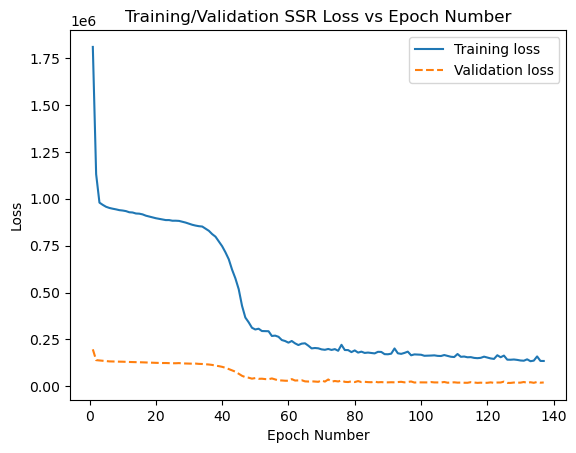

In [65]:
# Visualize the training/validation loss vs the epoch number with SSR
x = epoch_num_list
y1 = train_loss_list
y2 = val_loss_list

plt.plot(x, y1, label='Training loss', linestyle='-')
plt.plot(x, y2, label='Validation loss', linestyle='--')

plt.xlabel('Epoch Number')
plt.ylabel('Loss')
plt.title('Training/Validation SSR Loss vs Epoch Number')
plt.legend()
plt.show()

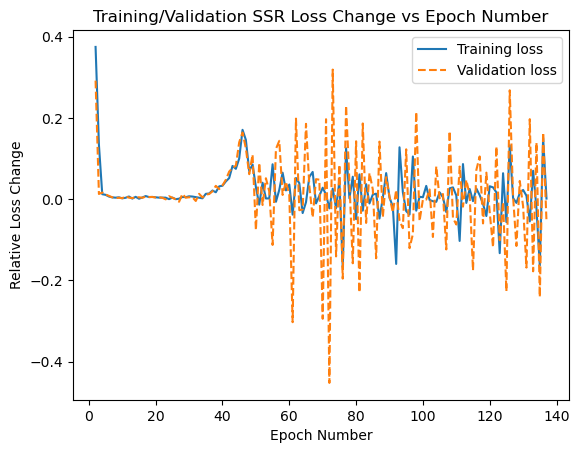

In [68]:
# Visualize the training/validation SSR loss relative change vs the epoch number
x = epoch_num_list[1:]
y1 = [-(train_loss_list[i] - train_loss_list[i-1])/train_loss_list[i-1] for i in range(1,len(train_loss_list))]
y2 = [-(val_loss_list[i] - val_loss_list[i-1])/val_loss_list[i-1] for i in range(1,len(val_loss_list))]

plt.plot(x, y1, label='Training loss', linestyle='-')
plt.plot(x, y2, label='Validation loss', linestyle='--')

plt.xlabel('Epoch Number')
plt.ylabel('Relative Loss Change')
plt.title('Training/Validation SSR Loss Change vs Epoch Number')
plt.legend()
plt.show()

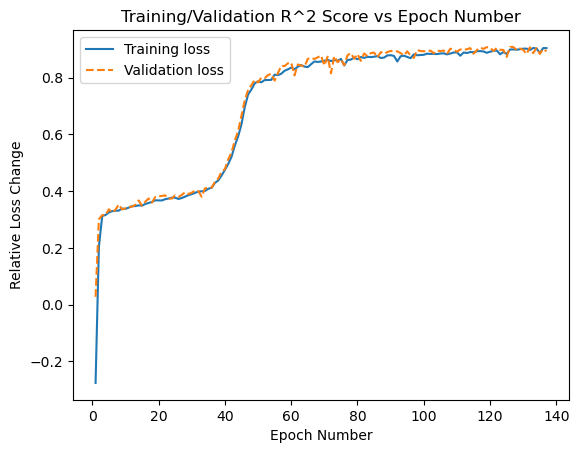

In [69]:
# Visualize the training/validation loss vs the epoch number with R^2
x = epoch_num_list
y1 = train_R_2_list
y2 = val_R_2_list

plt.plot(x, y1, label='Training loss', linestyle='-')
plt.plot(x, y2, label='Validation loss', linestyle='--')

plt.xlabel('Epoch Number')
plt.ylabel('Relative Loss Change')
plt.title('Training/Validation R^2 Score vs Epoch Number')
plt.legend()
plt.show()

### 14. Test the model (no need to run it if it's already saved)

In [72]:
# only one epoch needed

model.eval()

total_test_loss = 0
total_test_tss = 0

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        pred = model(batch)
        loss = ssr_loss(pred, batch.y.view(-1))
        target = batch.y.view(-1)
        TSS = torch.sum((target - target.mean())**2)
        total_test_loss += loss.item()
        total_test_tss += TSS
        
total_test_R_2 = R_2(total_val_loss, total_val_tss)
print(f"Testing SSR: {total_test_loss:.4f}, Testing R_2: {total_test_R_2:.4f}")

Testing SSR: 38552.9365, Testing R_2: 0.8932


### 15. Save the model parameters (trained weights and biases) (no need to run it if it's already saved)

In [73]:
# Here we want to save our trained model

In [74]:
dt_now = str(datetime.now())[:10]

In [75]:
type(model.state_dict())

collections.OrderedDict

In [76]:
model.state_dict().keys()

odict_keys(['conv1.att_src', 'conv1.att_dst', 'conv1.bias', 'conv1.lin.weight', 'conv2.att_src', 'conv2.att_dst', 'conv2.bias', 'conv2.lin.weight', 'conv3.att_src', 'conv3.att_dst', 'conv3.bias', 'conv3.lin.weight', 'conv4.att_src', 'conv4.att_dst', 'conv4.bias', 'conv4.lin.weight'])

In [77]:
len(model.state_dict().keys())

16

In [138]:
main_file = 'model_data_new_method'  # change the main file name if one day you want to change it
model_file = 'C:/Users/MECHREV/Desktop/本硕课程/二硕/Courses/AMATH 900 GNN/Data/data files/data files/'+main_file+'/m_wts_'+dt_now+'.pth'

In [79]:
torch.save(model.state_dict(),model_file)

### 16. Save the predicted responses (no need to run it if it's already saved)

In [133]:
len(list(data_tuple.keys()))

1000

In [134]:
list(data_tuple.keys())[0]

'gamma_100_reg_param_0.01_adh_0.01-Average-0'

In [135]:
data_tuple[list(data_tuple.keys())[0]]

Data(x=[886, 22], y=[2, 1], contact_edge_index=[2, 8940], lineage_edge_index=[2, 557])

In [136]:
full_loader = DataLoader(dataset, batch_size=10, shuffle=False)

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for batch in full_loader:
        batch = batch.to(device)
        pred = model(batch)           # shape: [batch_size]
        all_preds.append(pred.cpu())  # store predictions
        all_targets.append(batch.y.view(-1).cpu())  # store true targets

# Concatenate into a single tensor
all_preds = torch.cat(all_preds)     # shape: [num_graphs]
all_targets = torch.cat(all_targets) # shape: [num_graphs]

Graph 0: Predicted = 5.1460, Target = 10.0000
Graph 1: Predicted = -0.9850, Target = 0.1000
Graph 2: Predicted = 38.9610, Target = 40.0000
Graph 3: Predicted = -0.7831, Target = 0.0100
Graph 4: Predicted = 88.5379, Target = 100.0000


In [ ]:
torch.split(all_targets, 2, dim=0)[0]  # the target of first graph

In [ ]:
torch.split(all_preds, 2, dim=0)[0]  # the pred of first graph

In [141]:
data_dict = {}
L = []
for k,v in data_tuple.items():  # k = key (or graph name), v = value (or input features of the graph)
    
    in_channels_model = 22
    hidden_channels_model = 4 #attention heads
    feature_embedding_size = 5
    
    model = GAT(in_channels=in_channels_model, hidden_channels=hidden_channels_model, out_channels=feature_embedding_size)
    main_file = 'model_data_new_method'
    model_file = 'C:/Users/MECHREV/Desktop/本硕课程/二硕/Courses/AMATH 900 GNN/Data/data files/data files/'+main_file+'/m_wts_2025-06-08.pth'
    model.load_state_dict(torch.load(model_file))
    model.eval()
    
    with torch.no_grad():
        output = model(v)
    
    t = (v, output) # t = (input, output)
    
    data_dict[k] = t
    L.append(t)

In [142]:
len(L)

1000

In [143]:
len(data_dict.keys())

1000

In [144]:
list(data_dict.keys())[0]

'gamma_100_reg_param_0.01_adh_0.01-Average-0'

In [145]:
data_dict[list(data_dict.keys())[0]]

(Data(x=[886, 22], y=[2, 1], contact_edge_index=[2, 8940], lineage_edge_index=[2, 557]),
 tensor([81.1773,  2.4354]))

In [146]:
embedding_file = 'C:/Users/MECHREV/Desktop/本硕课程/二硕/Courses/AMATH 900 GNN/Data/data files/data files/'+main_file+'/embeddings_'+dt_now+'.pkl'
with open(embedding_file, 'wb') as f:
    pk.dump(data_dict, f)